<a href="https://colab.research.google.com/github/AlbinJosephcode/12-Steps-to-Navier-Stokes/blob/main/1D%20diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

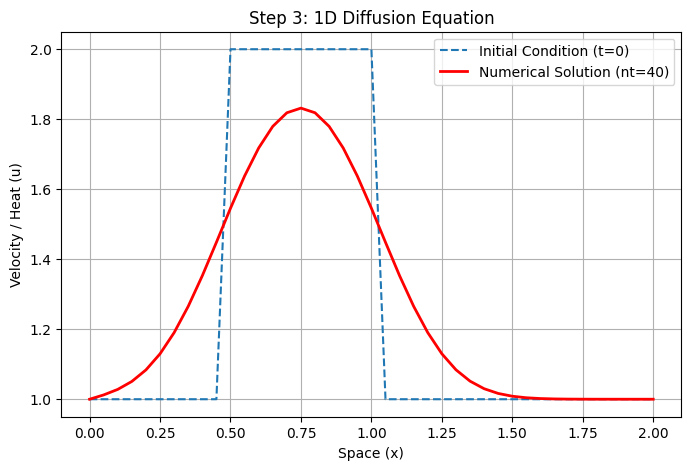

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters ---
nx = 41                 # Number of grid points
dx = 2.0 / (nx - 1)     # Distance between adjacent grid points
nt = 40                 # Number of time steps
nu = 0.3                # Kinematic viscosity / diffusivity
sigma = 0.2             # Courant parameter for diffusion (must be <= 0.5 for stability)
dt = sigma * dx**2 / nu # Calculate dt based on stability requirement

# --- 2. Initial Condition ---
x = np.linspace(0, 2, nx)
u = np.ones(nx)
u[(x >= 0.5) & (x <= 1.0)] = 2.0  # Square wave setup
u_initial = u.copy()

# Store spatial solution at every time step for 3D plotting
u_history = np.zeros((nt + 1, nx))
u_history[0, :] = u.copy()

# --- 3. Main Time-Stepping Solver Loop (FTCS Scheme) ---
for n in range(nt):
    un = u.copy()
    # Central difference in space for interior points
    for i in range(1, nx - 1):
        u[i] = un[i] + nu * (dt / dx**2) * (un[i+1] - 2 * un[i] + un[i-1])

    # Dirichlet Boundary Conditions
    u[0] = 1.0
    u[-1] = 1.0

    # Save current step to history matrix
    u_history[n + 1, :] = u.copy()

# --- 4. Standard 2D Plot (u vs x) ---
plt.figure(figsize=(8, 5))
plt.plot(x, u_initial, label='Initial Condition (t=0)', linestyle='--')
plt.plot(x, u, label=f'Numerical Solution (nt={nt})', color='red', linewidth=2)
plt.xlabel('Space (x)')
plt.ylabel('Velocity / Heat (u)')
plt.title('Step 3: 1D Diffusion Equation')
plt.legend()
plt.grid(True)
plt.show()

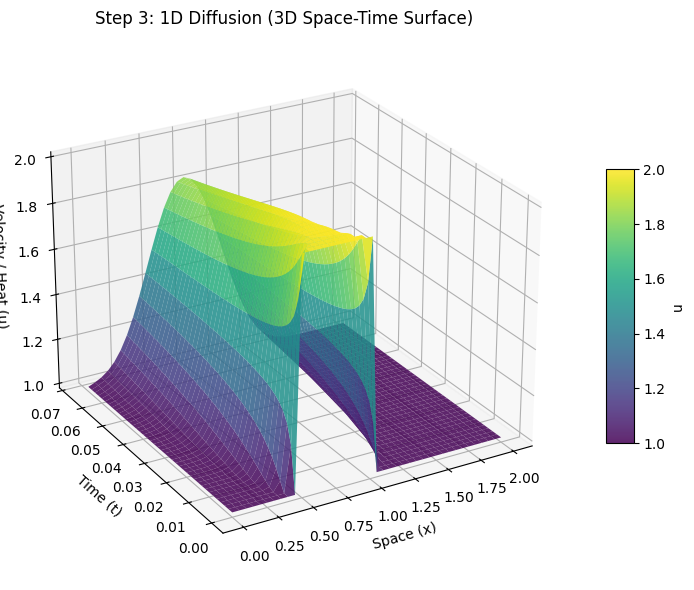

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate time vector and 2D spatial-temporal mesh
t_vec = np.linspace(0, nt * dt, nt + 1)
X, T = np.meshgrid(x, t_vec)

# --- 3D Surface Plot ---
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, T, u_history, cmap='viridis', edgecolor='none', alpha=0.85)

ax.set_xlabel('Space (x)')
ax.set_ylabel('Time (t)')
ax.set_zlabel('Velocity / Heat (u)')
ax.set_title('Step 3: 1D Diffusion (3D Space-Time Surface)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='u')

# Set viewing angle
ax.view_init(elev=25, azim=-120)
plt.tight_layout()
plt.show()
